In [5]:
import pandas as pd
import numpy as np
import ast
import matplotlib
import matplotlib.pyplot as plt
import os

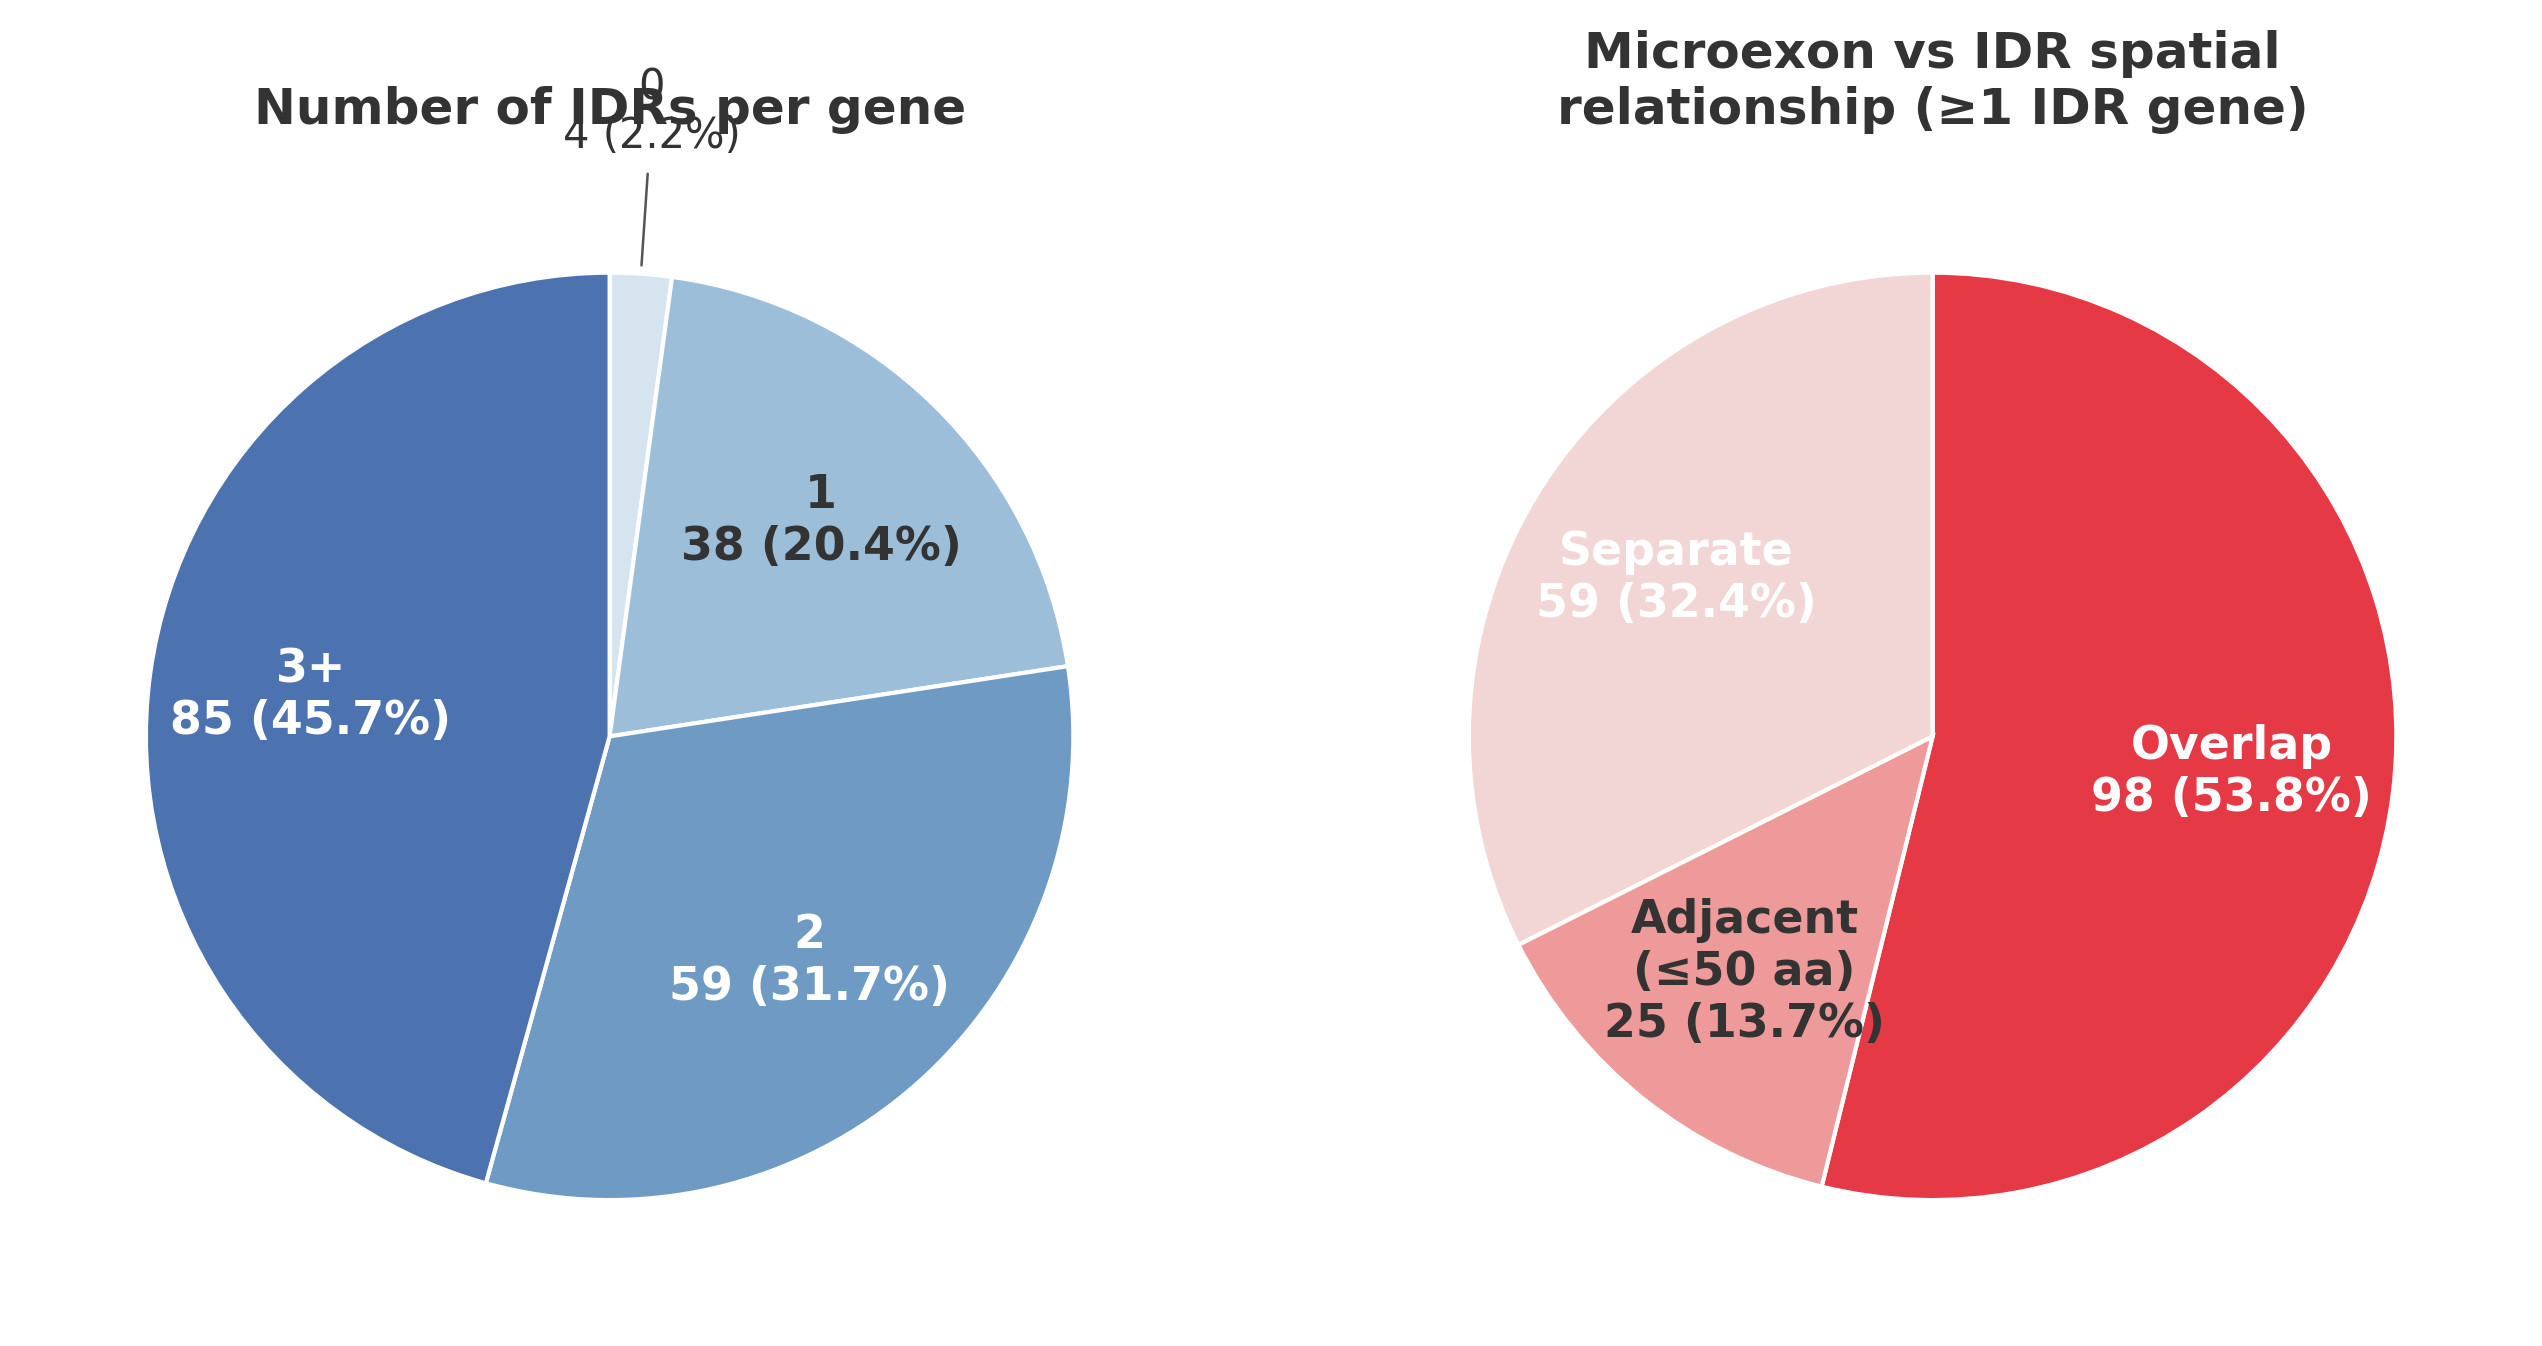

In [6]:
# ---- Config ----
CSV_PATH = "../outputs/microexon_final.csv"
OUT_DIR = "../outputs/"
FONT_SIZE = 12  # Cell-appropriate size

# ---- Fonts: Arial ----
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FONT_SIZE,
    "figure.dpi": 300, "savefig.dpi": 300,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ---- Load data ----
df = pd.read_csv(CSV_PATH)

def parse_boundaries(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

in_dis = df["in_disorder"].astype(str).str.upper().replace(
    {"TRUE": True, "0": False, "FALSE": False})

# ---- Pie 1: IDR number distribution (0, 1, 2, 3+) ----
# Sequential blue palette (ordinal data: 0 -> 3+)
idr_labels = ["0", "1", "2", "3+"]
idr_sizes = [
    (df["IDR #"] == 0).sum(),
    (df["IDR #"] == 1).sum(),
    (df["IDR #"] == 2).sum(),
    (df["IDR #"] >= 3).sum(),
]
idr_colors = ["#D6E4F0", "#9DBED9", "#6E9AC4", "#4C72B0"]  # light -> #4C72B0 (steel blue)
idr_wedge_labels = [f"{l}\n{s} ({s/len(df)*100:.1f}%)" for l, s in zip(idr_labels, idr_sizes)]

# ---- Pie 2: Microexon vs IDR spatial relationship (genes with >=1 IDR only) ----
df_idr = df[df["IDR #"] > 0].reset_index(drop=True)
in_dis_idr = in_dis[df["IDR #"] > 0].reset_index(drop=True)
n_idr = len(df_idr)

overlap_count = 0
adjacent_50 = 0
separate = 0
for idx, row in df_idr.iterrows():
    es = int(row["exon_start"])
    ee = int(row["exon_end"])
    boundaries = parse_boundaries(row["disordered_domain_boundaries"])
    if in_dis_idr[idx]:
        overlap_count += 1
        continue
    min_dist = float("inf")
    for (idr_start, idr_end) in boundaries:
        if ee <= idr_start:
            dist = idr_start - ee
        elif es >= idr_end:
            dist = es - idr_end
        else:
            dist = 0
        min_dist = min(min_dist, dist)
    if min_dist <= 50:
        adjacent_50 += 1
    else:
        separate += 1

rel_labels = ["Overlap", "Adjacent\n(≤50 aa)", "Separate"]
rel_sizes = [overlap_count, adjacent_50, separate]
# Sequential reddish palette (ordinal: Overlap > Adjacent > Separate)
rel_colors = ["#E63946", "#EE9A9A", "#F2D5D5"]  # Overlap (dark #E63946) -> Adjacent -> Separate (light)
rel_wedge_labels = [f"{l}\n{s} ({s/n_idr*100:.1f}%)"
                    for l, s in zip(rel_labels, rel_sizes)]

# ---- Draw figure (Cell style: no suptitle, clean, minimal) ----
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), facecolor="white")

def draw_pie(ax, sizes, colors, title, labels):
    """Draw pie with labels inside wedges; tiny wedges use a leader line."""
    wedges, _ = ax.pie(
        sizes, colors=colors, startangle=90, counterclock=False,
        wedgeprops=dict(edgecolor="white", linewidth=1),
    )
    ax.set_title(title, fontsize=FONT_SIZE, fontweight="bold",
                 pad=8, color="#333333")
    for w, lab in zip(wedges, labels):
        ang = (w.theta2 + w.theta1) / 2.0
        x = np.cos(np.deg2rad(ang)) * 0.65
        y = np.sin(np.deg2rad(ang)) * 0.65
        frac = (w.theta2 - w.theta1) / 360.0
        if frac >= 0.06:
            # Choose text color based on background darkness
            ax.text(x, y, lab, ha="center", va="center",
                    fontsize=FONT_SIZE - 1, fontweight="bold",
                    color="white" if frac > 0.25 else "#333333")
        else:
            x_out = np.cos(np.deg2rad(ang)) * 1.35
            y_out = np.sin(np.deg2rad(ang)) * 1.35
            ax.annotate(lab, xy=(np.cos(np.deg2rad(ang)) * 1.0,
                                 np.sin(np.deg2rad(ang)) * 1.0),
                        xytext=(x_out, y_out),
                        ha="center" if -0.3 < x_out < 0.3
                        else ("left" if x_out > 0 else "right"),
                        va="center", fontsize=FONT_SIZE - 2,
                        color="#333333",
                        arrowprops=dict(arrowstyle="-", color="#555555",
                                        linewidth=0.6))

draw_pie(axes[0], idr_sizes, idr_colors,
         "Number of IDRs per gene", idr_wedge_labels)
draw_pie(axes[1], rel_sizes, rel_colors,
         "Microexon vs IDR spatial\nrelationship (≥1 IDR gene)", rel_wedge_labels)

fig.tight_layout()

path_png = os.path.join(OUT_DIR, "microexon_idr_pies.png")
path_svg = os.path.join(OUT_DIR, "microexon_idr_pies.svg")
fig.savefig(path_png, bbox_inches="tight", facecolor="white")
fig.savefig(path_svg, bbox_inches="tight", facecolor="white")
plt.close()
print(f"Saved: {path_png}")
print(f"Saved: {path_svg}")

# Print summary
print(f"\nPie 1 — IDR number per gene:")
for l, s in zip(idr_labels, idr_sizes):
    print(f"  {l}: {s} ({s/len(df)*100:.1f}%)")
print(f"\nPie 2 — Microexon vs IDR relationship (genes with >=1 IDR, n={n_idr}):")
for l, s in zip(["Overlap", "Adjacent <=50aa", "Separate"], rel_sizes):
    print(f"  {l}: {s} ({s/n_idr*100:.1f}%)")